In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

df = pd.read_csv('C:/Users/domcs/Desktop/Egyetem/Titanic.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df.drop_duplicates(inplace=True)

df_clean = df.drop('Passengerid', axis=1)

print(f"Hiányzó adatok száma:\n{df_clean.isnull().sum()}")

Hiányzó adatok száma:
Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    0
Survived    0
dtype: int64


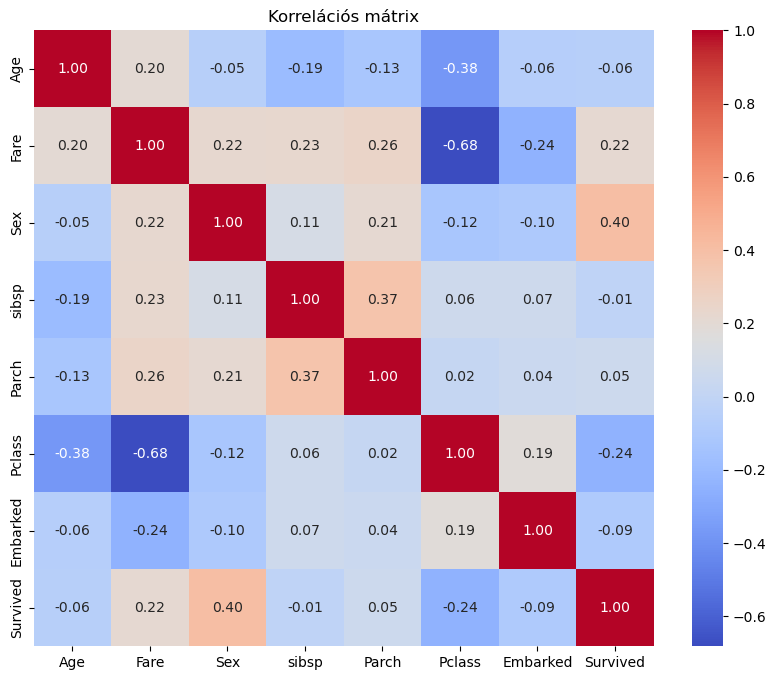

In [6]:
upper_limit = df_clean['Fare'].quantile(0.95)
df_clean['Fare'] = np.where(df_clean['Fare'] > upper_limit, upper_limit, df_clean['Fare'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korrelációs mátrix")
plt.show()

In [7]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
log_reg = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)

log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

print("--- Logisztikus Regresszió ---")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("--- KNN (k=5) ---")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

--- Logisztikus Regresszió ---
[[174  15]
 [ 46  27]]
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       189
           1       0.64      0.37      0.47        73

    accuracy                           0.77       262
   macro avg       0.72      0.65      0.66       262
weighted avg       0.75      0.77      0.74       262

--- KNN (k=5) ---
[[161  28]
 [ 42  31]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       189
           1       0.53      0.42      0.47        73

    accuracy                           0.73       262
   macro avg       0.66      0.64      0.65       262
weighted avg       0.72      0.73      0.72       262



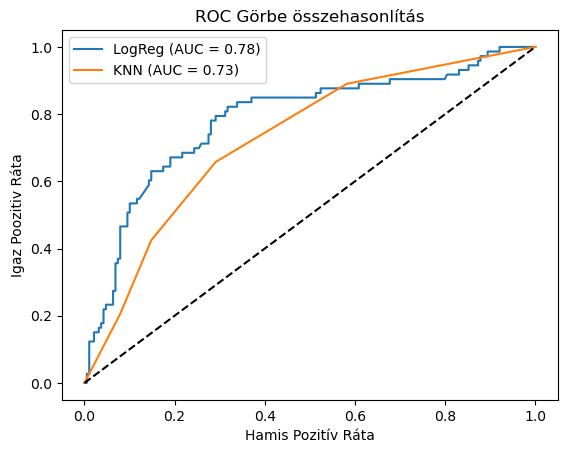

In [10]:
y_score_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_score_knn = knn.predict_proba(X_test_scaled)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_score_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)

plt.plot(fpr_log, tpr_log, label=f'LogReg (AUC = {auc(fpr_log, tpr_log):.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Hamis Pozitív Ráta')
plt.ylabel('Igaz Poozitiv Ráta')
plt.legend()
plt.title('ROC Görbe összehasonlítás')
plt.show()

In [12]:
data = [[30.0, 20.0, 1, 0, 0, 3, 2.0]] 
new_passenger = pd.DataFrame(data, columns=X.columns)
new_passenger_scaled = scaler.transform(new_passenger)

prob_log = log_reg.predict_proba(new_passenger_scaled)[0][1]
prob_knn = knn.predict_proba(new_passenger_scaled)[0][1]

print(f"Logisztikus Regresszió túlélési esély: {prob_log:.2%}")
print(f"KNN túlélési esély: {prob_knn:.2%}")

Logisztikus Regresszió túlélési esély: 36.01%
KNN túlélési esély: 40.00%
